In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("Dataset.csv")

target_col = "quality"
feature_cols = [c for c in df.columns if c != target_col]

X_raw = df[feature_cols].values.astype(float)
y = df[target_col].values.astype(float)

# standardize each feature (critical for multi-feature GD to converge evenly)
X_mean = X_raw.mean(axis=0)
X_std = X_raw.std(axis=0)
X_norm = (X_raw - X_mean) / X_std

n, p = X_norm.shape
X_b = np.column_stack([np.ones(n), X_norm])   # add bias column -> shape (n, p+1)

print(X_b.shape, y.shape)

(6497, 12) (6497,)


In [2]:
## Multiple linear regression via gradient descent (with divergence guard)
def multi_gradient_descent(X_b, y, lr=0.01, tol=1e-6, max_iter=200000, record_every=1):
    """
    X_b: (n, p+1) design matrix with bias column already included.
    Returns: beta (final), history DataFrame with one row per recorded iteration.
    """
    n, p1 = X_b.shape
    beta = np.zeros(p1)
    prev_mse = np.inf

    records = []

    for k in range(max_iter):
        y_pred = X_b @ beta
        error = y_pred - y
        mse = np.mean(error ** 2)
        mae = np.mean(np.abs(error))

        if not np.isfinite(mse):
            raise FloatingPointError(f"Diverged at iter {k} with lr={lr}")

        # adaptive lr: shrink if loss increases
        if mse > prev_mse:
            lr *= 0.5
        prev_mse = mse

        if k % record_every == 0:
            row = {"iter": k, "mse": mse, "mae": mae}
            for j in range(p1):
                row[f"beta{j}"] = beta[j]
            records.append(row)

        grad = (2 / n) * (X_b.T @ error)
        beta_new = beta - lr * grad

        if np.max(np.abs(beta_new - beta)) <= tol:
            beta = beta_new
            row = {"iter": k + 1, "mse": mse, "mae": mae}
            for j in range(p1):
                row[f"beta{j}"] = beta[j]
            records.append(row)
            break

        beta = beta_new

    return beta, pd.DataFrame(records)

In [3]:
beta_final, hist_multi = multi_gradient_descent(X_b, y, lr=0.01, tol=1e-6, max_iter=200000)

# name columns clearly: beta0 = intercept, beta1..beta11 = features in feature_cols order
col_names = ["beta0"] + [f"beta_{f}" for f in feature_cols]
rename_map = {f"beta{j}": col_names[j] for j in range(len(col_names))}
hist_multi = hist_multi.rename(columns=rename_map)

hist_multi.to_csv("ass2-2_gradient_updates.csv", index=False)

print("Converged in", len(hist_multi), "recorded iterations")
print(dict(zip(col_names, beta_final)))

Converged in 6444 recorded iterations
{'beta0': 5.818377712790497, 'beta_fixed_acidity': 0.08702910533407522, 'beta_volatile_acidity': -0.21878297385061338, 'beta_citric_acid': -0.015931484882793126, 'beta_residual_sugar': 0.20627139837138203, 'beta_chlorides': -0.0170373134704058, 'beta_free_sulfur_dioxide': 0.10595423107763605, 'beta_total_sulfur_dioxide': -0.14010346495436787, 'beta_density': -0.16329406838511273, 'beta_pH': 0.07018882660482088, 'beta_sulphates': 0.11414736832400531, 'beta_alcohol': 0.3191793469141088}


R^2 (multiple linear regression) = 0.2921
Shapiro-Wilk: stat=0.9891, p=3.34e-19


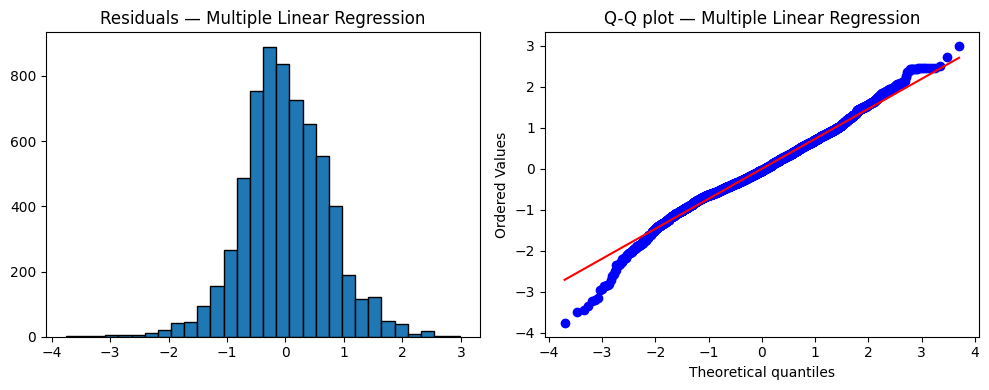

In [4]:
## R² and residual normality for the full model
def r_squared(y, y_pred):
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - ss_res / ss_tot

y_pred_multi = X_b @ beta_final
r2_multi = r_squared(y, y_pred_multi)
residuals_multi = y - y_pred_multi

print(f"R^2 (multiple linear regression) = {r2_multi:.4f}")

from scipy import stats
shapiro_stat, shapiro_p = stats.shapiro(
    residuals_multi if len(residuals_multi) <= 5000
    else np.random.choice(residuals_multi, 5000, replace=False)
)
print(f"Shapiro-Wilk: stat={shapiro_stat:.4f}, p={shapiro_p:.4g}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(residuals_multi, bins=30, edgecolor="k")
axes[0].set_title("Residuals — Multiple Linear Regression")
stats.probplot(residuals_multi, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot — Multiple Linear Regression")
plt.tight_layout()
plt.savefig("ass2-2_residuals.png", dpi=100)
plt.show()

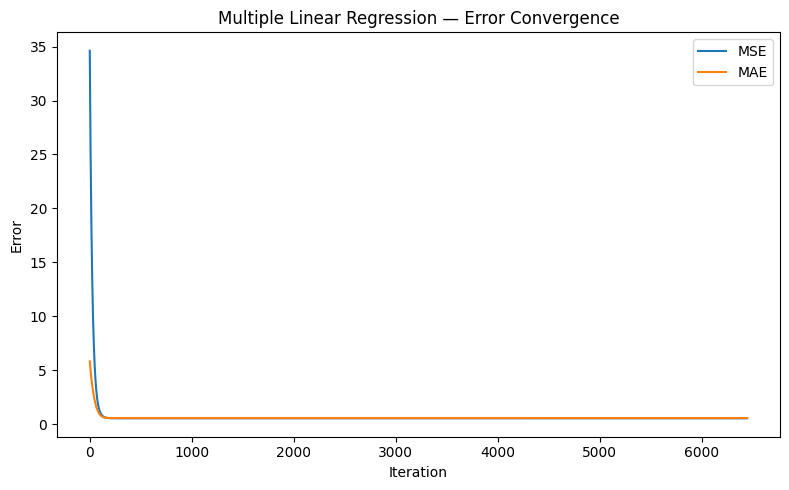

In [5]:
## Convergence plot (MSE/MAE vs iteration, since 12-D β can't be shown on x/y/z axes directly)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(hist_multi["iter"], hist_multi["mse"], label="MSE")
ax.plot(hist_multi["iter"], hist_multi["mae"], label="MAE")
ax.set_xlabel("Iteration")
ax.set_ylabel("Error")
ax.set_title("Multiple Linear Regression — Error Convergence")
ax.legend()
plt.tight_layout()
plt.savefig("ass2-2_convergence.png", dpi=100)
plt.show()

# Question 3 — Polynomial Regression (all features, feature-wise degree choice)

In [6]:
# Reuse X_raw, y, feature_cols from Question 2 setup

# degree for feature j (1-indexed, per the assignment's own formula: x1^1, x2^2, ..., x11^11)
degrees = list(range(1, len(feature_cols) + 1))  # [1, 2, 3, ..., 11]

X_poly = np.column_stack([
    X_raw[:, j] ** degrees[j] for j in range(len(feature_cols))
])

# standardize each polynomial feature (essential -- x^11 has a wildly different scale than x^1)
X_poly_mean = X_poly.mean(axis=0)
X_poly_std = X_poly.std(axis=0)
X_poly_norm = (X_poly - X_poly_mean) / X_poly_std

n, p = X_poly_norm.shape
X_poly_b = np.column_stack([np.ones(n), X_poly_norm])

print(X_poly_b.shape)
print(dict(zip(feature_cols, degrees)))

(6497, 12)
{'fixed_acidity': 1, 'volatile_acidity': 2, 'citric_acid': 3, 'residual_sugar': 4, 'chlorides': 5, 'free_sulfur_dioxide': 6, 'total_sulfur_dioxide': 7, 'density': 8, 'pH': 9, 'sulphates': 10, 'alcohol': 11}


In [7]:
print(pd.DataFrame(X_poly, columns=feature_cols).describe())

       fixed_acidity  volatile_acidity  citric_acid  residual_sugar  \
count    6497.000000       6497.000000  6497.000000    6.497000e+03   
mean        7.215307          0.142474     0.053980    1.203354e+04   
std         1.296434          0.158471     0.096924    2.342957e+05   
min         3.800000          0.006400     0.000000    1.296000e-01   
25%         6.400000          0.052900     0.015625    1.049760e+01   
50%         7.000000          0.084100     0.029791    8.100000e+01   
75%         7.700000          0.160000     0.059319    4.304672e+03   
max        15.900000          2.496400     4.574296    1.874578e+07   

          chlorides  free_sulfur_dioxide  total_sulfur_dioxide      density  \
count  6.497000e+03         6.497000e+03          6.497000e+03  6497.000000   
mean   6.552017e-05         1.080799e+11          3.894229e+15     0.958597   
std    1.616765e-03         7.230704e+12          4.287470e+16     0.023263   
min    5.904900e-11         1.000000e+00    

In [8]:
X_raw_norm_first = (X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)
X_poly = np.column_stack([
    X_raw_norm_first[:, j] ** degrees[j] for j in range(len(feature_cols))
])

In [10]:
# Reusing the same multi_gradient_descent function from Q2
beta_poly, hist_poly = multi_gradient_descent(X_poly_b, y, lr=0.01, tol=1e-6, max_iter=200000)

col_names_poly = ["beta0"] + [f"beta_{feature_cols[j]}^{degrees[j]}" for j in range(len(feature_cols))]
rename_map = {f"beta{j}": col_names_poly[j] for j in range(len(col_names_poly))}
hist_poly = hist_poly.rename(columns=rename_map)

hist_poly.to_csv("ass2-3_gradient_updates.csv", index=False)

print("Converged in", len(hist_poly), "iterations")
print(dict(zip(col_names_poly, beta_poly)))

Converged in 3442 iterations
{'beta0': 5.818377712790551, 'beta_fixed_acidity^1': 0.07468088096865544, 'beta_volatile_acidity^2': -0.22885601773449815, 'beta_citric_acid^3': -0.021892847600055332, 'beta_residual_sugar^4': 0.038162190448670676, 'beta_chlorides^5': -0.014962848455085406, 'beta_free_sulfur_dioxide^6': 0.0790948368733114, 'beta_total_sulfur_dioxide^7': -0.1259676950085257, 'beta_density^8': -0.09392936592303433, 'beta_pH^9': 0.06368956272628899, 'beta_sulphates^10': 0.0006814548400228407, 'beta_alcohol^11': 0.27585402276557974}


R^2 (polynomial regression) = 0.2201
Shapiro-Wilk: stat=0.9849, p=9.59e-23


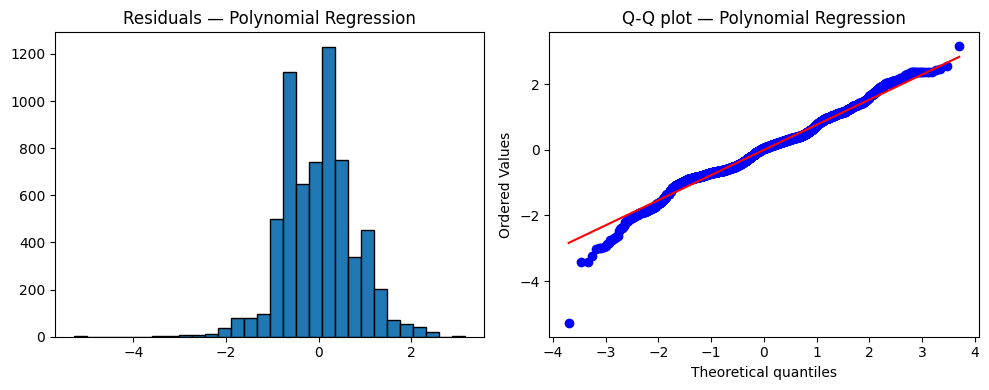

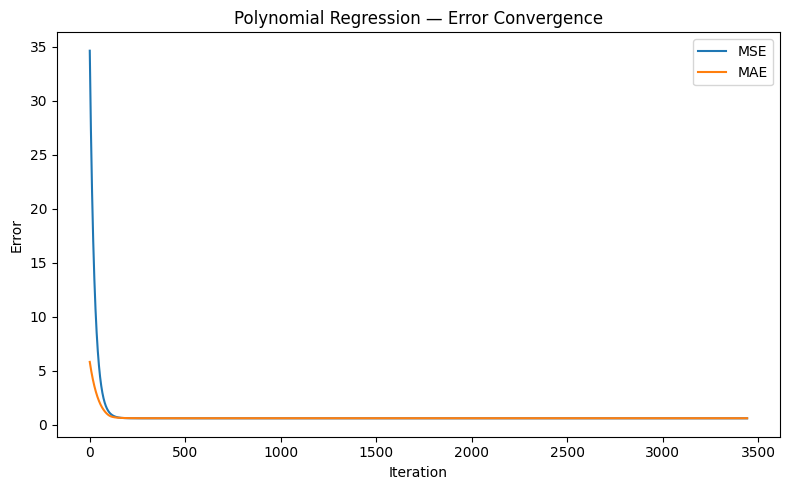

In [11]:
## R², residuals, convergence plot
y_pred_poly = X_poly_b @ beta_poly
r2_poly = r_squared(y, y_pred_poly)
residuals_poly = y - y_pred_poly

print(f"R^2 (polynomial regression) = {r2_poly:.4f}")

shapiro_stat_p, shapiro_p_p = stats.shapiro(
    residuals_poly if len(residuals_poly) <= 5000
    else np.random.choice(residuals_poly, 5000, replace=False)
)
print(f"Shapiro-Wilk: stat={shapiro_stat_p:.4f}, p={shapiro_p_p:.4g}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(residuals_poly, bins=30, edgecolor="k")
axes[0].set_title("Residuals — Polynomial Regression")
stats.probplot(residuals_poly, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot — Polynomial Regression")
plt.tight_layout()
plt.savefig("ass2-3_residuals.png", dpi=100)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(hist_poly["iter"], hist_poly["mse"], label="MSE")
ax.plot(hist_poly["iter"], hist_poly["mae"], label="MAE")
ax.set_xlabel("Iteration")
ax.set_ylabel("Error")
ax.set_title("Polynomial Regression — Error Convergence")
ax.legend()
plt.tight_layout()
plt.savefig("ass2-3_convergence.png", dpi=100)
plt.show()

In [12]:
## Compare Q1 (best single feature) vs Q2 (multiple) vs Q3 (polynomial)
print(f"Best single-feature R^2 (from Q1)   : check your summary_all_features.csv")
print(f"Multiple linear regression R^2      : {r2_multi:.4f}")
print(f"Polynomial regression R^2           : {r2_poly:.4f}")

Best single-feature R^2 (from Q1)   : check your summary_all_features.csv
Multiple linear regression R^2      : 0.2921
Polynomial regression R^2           : 0.2201
